In [42]:
%load_ext autoreload
%autoreload 2

import numpy as np
import cv2
import json
from pathlib import Path
import matplotlib.pyplot as plt
from dataclasses import dataclass

from project_root import PROJECT_ROOT

from calib_utils import *

DATA_ROOT = PROJECT_ROOT/"data"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [43]:
# Load config
config_file = Path(DATA_ROOT / "config.json")
with config_file.open() as f:
    config = json.load(f)

zag_elp_cam_016
Number of polygons: 1
  Poly 0 point count=6


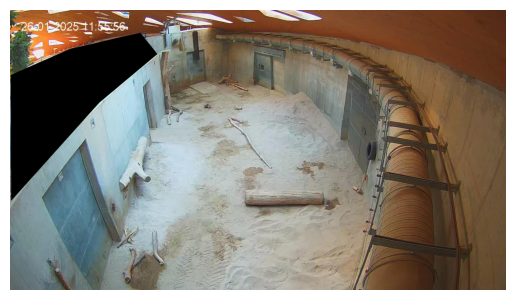

In [49]:
#######################################
# This is the camera we are calibrating
all_camera_names = [
    "elp_kamera_01",
    "zag_elp_cam_016",
    "zag_elp_cam_017",
    "zag_elp_cam_018",
    "zag_elp_cam_019",
]
camera_name = all_camera_names[1]  # <------CHANGE HERE
print(camera_name)
########################################

mask_polygons = config["cameras"][camera_name].get("mask_polygons", None)
if mask_polygons is not None:
    mask_polygons = [np.asarray(x) for x in mask_polygons]


def shape_or_none(v):
    if v is None:
        return None
    elif hasattr(v, "shape"):
        return v.shape
    else:
        return len(v)


print(f"Number of polygons: {shape_or_none(mask_polygons)}")
if mask_polygons is not None:
    for i, poly in enumerate(mask_polygons):
        print(f"  Poly {i} point count={poly.shape[0]}")

files = list(DATA_ROOT.glob(f"cameras/{camera_name}/*.jpg"))
assert len(files) > 0, "No image files found in camera dir. Need a sample image."
image_filename = files[0].relative_to(DATA_ROOT)

im_camera = imread_rgb(DATA_ROOT / image_filename)
height, width, _ = im_camera.shape

im_with_poly = im_camera.copy()
if mask_polygons is not None:
    for poly in mask_polygons:
        im_with_poly = cv2.fillConvexPoly(im_with_poly, poly, color=[0, 0, 0])

plt.imshow(im_with_poly)
plt.gca().set_axis_off()

In [45]:
# Draw floor polygon in camera
# floor_polygon_in_camera = None
if mask_polygons is None:
    mask_polygons = []

    image_clicker = MouseHandler(im_camera, "mask_polygons", is_polygon=True)
    cv2.startWindowThread()
    while True:
        image_clicker.start()
        key = cv2.waitKey(0)

        # Store clicks as polygon
        poly = np.array(image_clicker.positions)
        mask_polygons.append(poly)

        if key & 0xFF == ord("n"):
            continue
        else:
            break
    cv2.destroyAllWindows()

    print("Mask polygons:")
    display(mask_polygons)
else:
    print("Skipping")

Skipping


In [46]:
# Save
config["cameras"][camera_name]["mask_polygons"] = [x.tolist() for x in mask_polygons]
with config_file.open("w") as f:
    json.dump(config, f, indent=2)
print(f"Updated camera {camera_name} in config {str(config_file)}")

Updated camera zag_elp_cam_018 in config /home/dherrera/git/zoo_vision/data/config.json
